✓ Mac GPU 가속(MPS)이 활성화되었습니다.
Using device: mps
✓ 데이터셋 로드 성공
학습 데이터 수: 1070
테스트 데이터 수: 268

학습 시작...
Epoch [20/200] Train Loss: 35180952.5294 | Test Loss: 31105684.2222
Epoch [40/200] Train Loss: 31723057.3529 | Test Loss: 27574290.8889
Epoch [60/200] Train Loss: 28354675.6765 | Test Loss: 24846278.1111
Epoch [80/200] Train Loss: 27880123.0882 | Test Loss: 22845558.5556
Epoch [100/200] Train Loss: 26987172.5882 | Test Loss: 21802476.0000
Epoch [120/200] Train Loss: 25280153.2647 | Test Loss: 20961871.7778
Epoch [140/200] Train Loss: 25438171.1618 | Test Loss: 20489935.3333
Epoch [160/200] Train Loss: 24996309.2647 | Test Loss: 20007772.3333
Epoch [180/200] Train Loss: 24743930.5294 | Test Loss: 19790835.6667
Epoch [200/200] Train Loss: 22662511.7206 | Test Loss: 19550085.2222
학습 완료!

최종 모델 성능
MAE (평균 절대 오차): $2604.09
R² Score (결정 계수): 0.8699


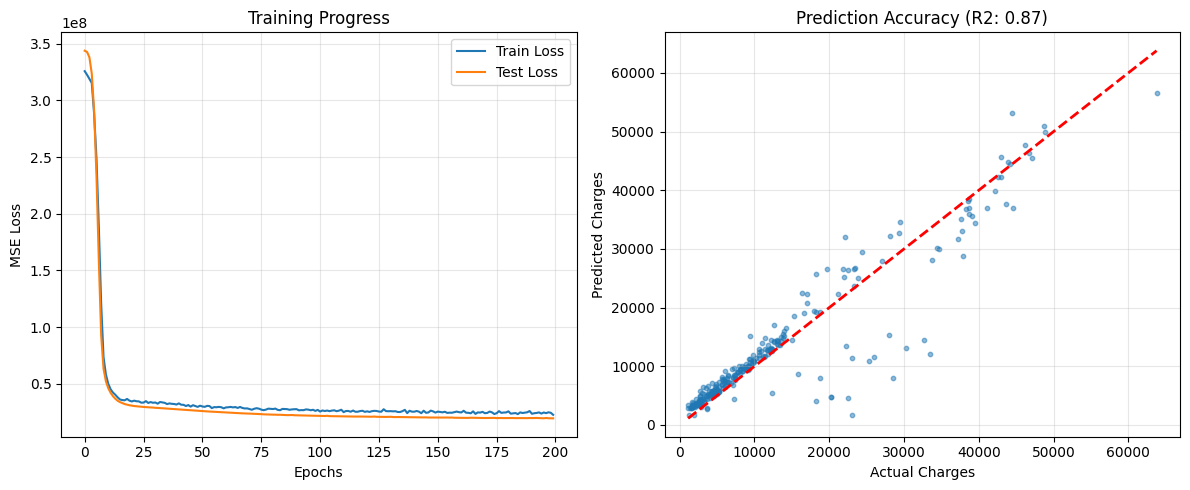

In [2]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Jupyter Notebook에서 그래프가 바로 보이도록 설정
%matplotlib inline

# ---------------------------------------------------------
# 1. 맥북(MPS) 및 GPU 설정
# ---------------------------------------------------------
# 랜덤 시드 고정
torch.manual_seed(42)
np.random.seed(42)

# 디바이스 확인 순서: CUDA(Nvidia) -> MPS(Mac) -> CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("✓ Mac GPU 가속(MPS)이 활성화되었습니다.")
else:
    device = torch.device('cpu')
    print("✓ CPU를 사용합니다.")

print(f"Using device: {device}")

# ---------------------------------------------------------
# 2. 데이터 로드 및 전처리
# ---------------------------------------------------------
# CSV 파일 로드
try:
    df = pd.read_csv('insurance.csv')
    print("✓ 데이터셋 로드 성공")
except FileNotFoundError:
    print("Error: 'insurance.csv' 파일을 찾을 수 없습니다. 노트북 파일과 같은 폴더에 넣어주세요.")
    raise

# 범주형 데이터(성별, 흡연여부, 지역)를 수치형으로 변환 (One-Hot Encoding)
# drop_first=True로 설정하여 불필요한 변수 중복 제거
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Feature(X)와 Target(y) 분리
X = df_encoded.drop('charges', axis=1).values.astype(np.float32) # float32로 명시적 변환
y = df_encoded['charges'].values.astype(np.float32).reshape(-1, 1)

# Train/Test 분리 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 정규화 (StandardScaler) - 학습 안정성을 위해 필수
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 텐서 변환 및 데이터셋 생성
# MPS 장치로 바로 올리지 않고 학습 루프에서 올리는 것이 메모리 관리에 유리함
train_dataset = TensorDataset(torch.from_numpy(X_train_scaled), torch.from_numpy(y_train))
test_dataset = TensorDataset(torch.from_numpy(X_test_scaled), torch.from_numpy(y_test))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"학습 데이터 수: {len(X_train)}")
print(f"테스트 데이터 수: {len(X_test)}")

# ---------------------------------------------------------
# 3. 모델 정의 (심층 신경망)
# ---------------------------------------------------------
class InsuranceModel(nn.Module):
    def __init__(self, input_dim):
        super(InsuranceModel, self).__init__()
        # 더 깊은 네트워크 구조와 Dropout 적용
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2), # 과적합 방지
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.net(x)

# 모델 초기화 및 디바이스 이동
input_dim = X_train.shape[1]
model = InsuranceModel(input_dim).to(device)

# 손실함수 및 옵티마이저
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------------------------------------------------------
# 4. 학습 (Training)
# ---------------------------------------------------------
num_epochs = 200
train_losses = []
test_losses = []

print("\n학습 시작...")

for epoch in range(num_epochs):
    # Train Mode
    model.train()
    batch_loss = 0
    
    for X_batch, y_batch in train_loader:
        # 데이터를 맥북 GPU(MPS)로 이동
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        batch_loss += loss.item()
    
    train_losses.append(batch_loss / len(train_loader))
    
    # Test Mode (Validation)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()
            
    test_losses.append(test_loss / len(test_loader))
    
    # 20 에폭마다 로그 출력
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f}")

print("학습 완료!")

# ---------------------------------------------------------
# 5. 결과 시각화 및 평가
# ---------------------------------------------------------
# Loss 그래프
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)

# 최종 예측 및 평가
model.eval()
with torch.no_grad():
    # 전체 테스트 데이터를 디바이스로 옮겨서 예측
    X_test_device = torch.from_numpy(X_test_scaled).to(device)
    pred_tensor = model(X_test_device)
    
    # 결과를 다시 CPU로 가져와서 Numpy 변환 (그래프 및 sklearn 계산용)
    y_pred = pred_tensor.cpu().numpy()
    y_true = y_test

# 평가 지표 계산
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n" + "="*40)
print("최종 모델 성능")
print("="*40)
print(f"MAE (평균 절대 오차): ${mae:.2f}")
print(f"R² Score (결정 계수): {r2:.4f}")
print("="*40)

# 실제값 vs 예측값 산점도
plt.subplot(1, 2, 2)
plt.scatter(y_true, y_pred, alpha=0.5, s=10)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title(f'Prediction Accuracy (R2: {r2:.2f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()